In [1]:
#import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#read data & set theme
df = pd.read_csv('../data/Loan_Default.csv')
sns.set_theme(style='whitegrid')

In [3]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


Số lượng vỡ nợ: 36639
Tỷ lệ vỡ nợ: 24.64%


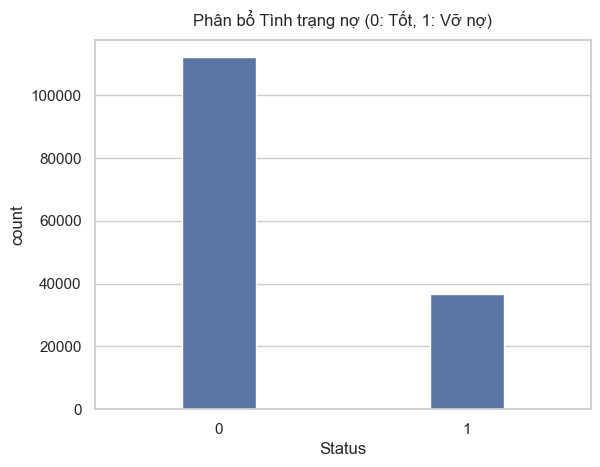

In [4]:
#Tính tỷ lệ phần trăm vỡ nợ
target = sns.countplot(data=df, x='Status', width=0.3)
target.set_title("Phân bổ Tình trạng nợ (0: Tốt, 1: Vỡ nợ)",pad=10)
total = len(df)
status_counts = df['Status'].value_counts()
rate = (status_counts[1] / (status_counts[0] + status_counts[1])) * 100
print(f"Số lượng vỡ nợ: {status_counts[1]}")
print(f"Tỷ lệ vỡ nợ: {rate:.2f}%")

#Dữ liệu có sự mất cân bằng nghiêm trọng(24.64% vỡ nợ, 75.36% tốt)

#Status là biến phân loại(Categorical), nên countplot giúp phát hiện độ lệch giữa 2 nhóm (0 và 1) bằng cách nhìn độ cao của cột.

Text(0, 0.5, 'Tỷ lệ phần trăm')

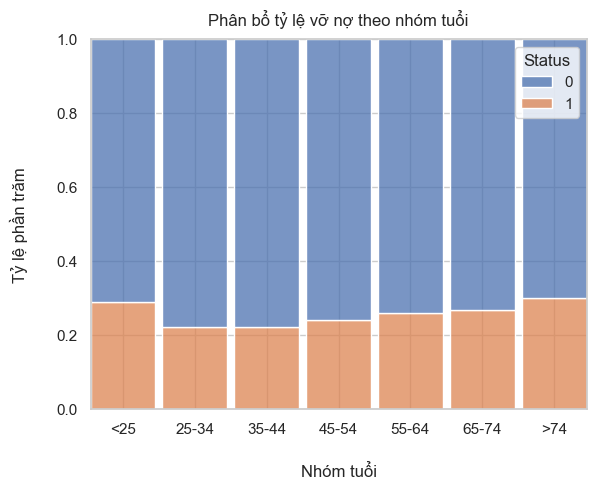

In [5]:
#Phân bổ tỷ lệ vỡ nợ theo nhóm tuổi
age_order= ["<25", "25-34","35-44","45-54","55-64","65-74",">74"]
df['age'] = pd.Categorical(df['age'], categories=age_order,ordered=True)
age_status = sns.histplot(data=df, x='age', hue='Status', multiple='fill',shrink=0.9)
age_status.set_title("Phân bổ tỷ lệ vỡ nợ theo nhóm tuổi",pad =10)
age_status.set_xlabel("Nhóm tuổi",labelpad=20)
age_status.set_ylabel("Tỷ lệ phần trăm",labelpad=20)

#Nhóm tỷ lệ vỡ nợ(màu cam) ở 2 nhóm tuổi <25 và >74 cao hơn các nhóm tuổi còn lại => Những người quá trẻ hoặc quá già có tỷ lệ vỡ nợ cao hơn. Trong khi đó, tỷ lệ vỡ nợ có xu hướng tăng lên theo các nhóm tuổi từ 25-74
#Histplot fill giúp so sánh tỷ lệ rủi ro công băng giữa các nhóm tuổi (Bỏ qua số lượng)


Text(0, 0.5, 'Số lượng hồ sơ')

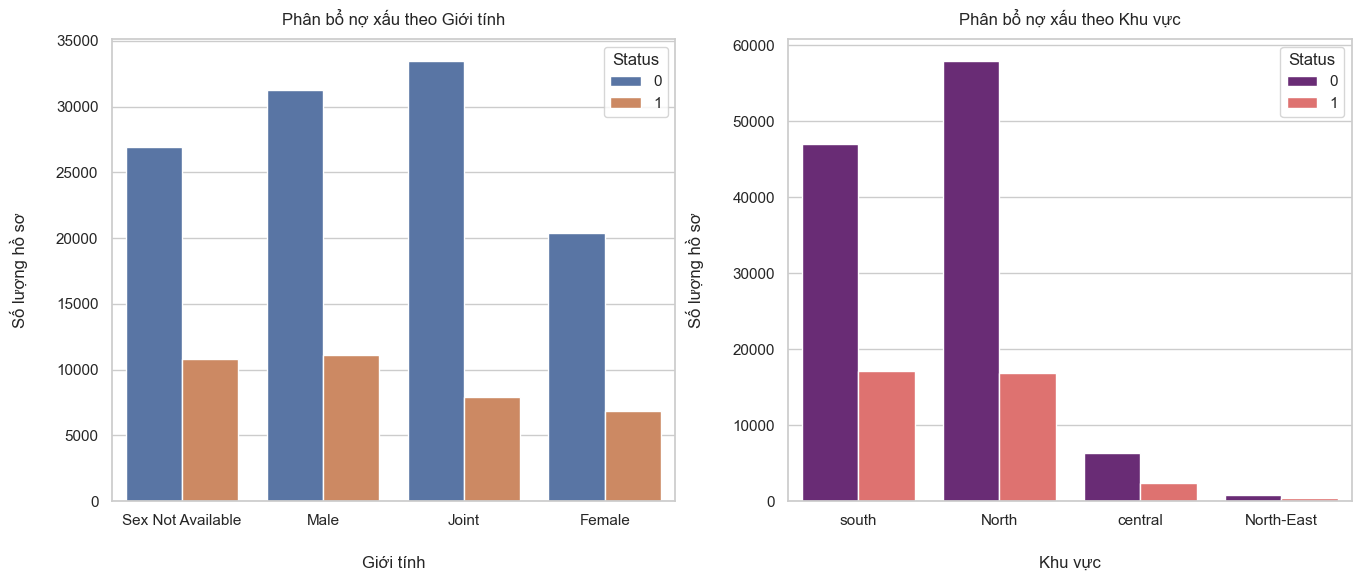

In [6]:
#Phân bổ tình trạng vỡ nợ theo giới tính và khu vực
#Biểu đồ 1: Gender
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=df, x='Gender', hue='Status', ax=axes[0])
axes[0].set_title("Phân bổ nợ xấu theo Giới tính",pad=10)
axes[0].set_xlabel("Giới tính", labelpad=20)
axes[0].set_ylabel("Số lượng hồ sơ",labelpad=20)
# Biểu đồ 2: Region
sns.countplot(data=df, x='Region', hue='Status', ax=axes[1],palette='magma')
axes[1].set_title("Phân bổ nợ xấu theo Khu vực",pad=10)
axes[1].set_xlabel("Khu vực",labelpad=20)
axes[1].set_ylabel("Số lượng hồ sơ",labelpad=20)

#Phân tích theo giới tính

#Nhóm an toàn nhất: Hồ sơ vay chung (Joint) chiếm số lượng lớn nhất và có tỷ lệ vỡ nợ (cột cam) thấp hơn so với các nhóm khác.

#Nhóm rủi ro nhất: Nhóm khách hàng Nam (Male) và nhóm không có thông tin giới tính (Sex Not Available) có tỷ lệ cột màu cam khá cao.

#Vấn đề dữ liệu: Một lượng lớn hồ sơ nàm ở cột "Sex Not available" cần được làm sạch để tránh thông tin sai lệch.

#Phân tích theo khu vực

#Thị trường chủ yếu: Miền Bắc (North) và miền Nam (south) là hai khu vực chiếm số lượng hồ sơ áp đảo => là hai thị trường mục tiêu chính của mô hình.

#Rủi ro cao tại miền Nam: Tỷ lệ vỡ nợ ở miền Nam có xu hướng cao hơn miền Bắc vì tổng hồ sơ ít hơn miền Bắc.

#Dữ liệu ít: Khu vực central và North-East có dữ liệu ít khiến việc xác định khó khăn hơn.
